In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

con = duckdb.connect('../capillary.db')

df = con.execute("SELECT value, manual_classification as label FROM protein_data WHERE manual_classification IS NOT NULL AND value IS NOT NULL").df()

df = df[df['value'].apply(len) == 301]
X = np.array(df['value'].tolist(), dtype=np.float32)
y = np.array(df['label'].tolist(), dtype=np.int8)

# Sista kolumnen är skräp i X.
X = X[:, :300]
np.shape(X)
np.shape(y)

con.close()

In [ ]:
class_weight = {0: 1.0, 1: 74/26}

# Först: låt 15% vara test-set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Sedan: dela resten i träning/validering (0.1765 ≈ 15% av totalen)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y[: len(y_temp)]
)

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(y):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(y):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(y):.0%})")

Träning:    105658 (70%)
Validering:  22646 (15%)
Test:        22643 (15%)


In [12]:
batch_sz = 64

# DataLoaders
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_sz)

for X, y in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(300, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(model)

Shape of X: torch.Size([64, 300])
Shape of y: torch.Size([64])
Using mps device
NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [14]:
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)

epochs = 50
accuracies = []
avg_losses = []
for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = validate(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epooch {t}, accuracy: {accuracy}, Avg loss: {avg_loss}")
    accuracies.append(accuracy)
    avg_losses.append(avg_loss)
print("Done!")

Epooch 0, accuracy: 88.08619623774618, Avg loss: 0.3475923404350119
Epooch 1, accuracy: 91.51726574229444, Avg loss: 0.22809711828996232
Epooch 2, accuracy: 91.11101298242515, Avg loss: 0.26513773160802445
Epooch 3, accuracy: 91.11542877329329, Avg loss: 0.23525922903317517
Epooch 4, accuracy: 92.96564514704583, Avg loss: 0.21564511209726334
Epooch 5, accuracy: 92.9523977744414, Avg loss: 0.2125431485053173
Epooch 6, accuracy: 92.55939238717654, Avg loss: 0.21836850488042764
Epooch 7, accuracy: 93.73840854897112, Avg loss: 0.1793900712124877
Epooch 8, accuracy: 94.40960876092909, Avg loss: 0.1654470351835092
Epooch 9, accuracy: 94.53766669610528, Avg loss: 0.16243892676581098
Epooch 10, accuracy: 94.53325090523713, Avg loss: 0.16312818433352783
Epooch 11, accuracy: 91.97650799258147, Avg loss: 0.2281822715438692
Epooch 12, accuracy: 94.22856133533516, Avg loss: 0.17429581991696763
Epooch 13, accuracy: 93.83997173893844, Avg loss: 0.18556716505669604
Epooch 14, accuracy: 94.436103506137

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Samla alla prediktioner
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in val_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Rapport
print(classification_report(all_labels, all_preds, target_names=['Negativ', 'Positiv']))

# Konfusionsmatris
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

     Negativ       0.96      0.98      0.97     16884
     Positiv       0.95      0.87      0.91      5762

    accuracy                           0.96     22646
   macro avg       0.95      0.93      0.94     22646
weighted avg       0.96      0.96      0.96     22646

[[16619   265]
 [  733  5029]]


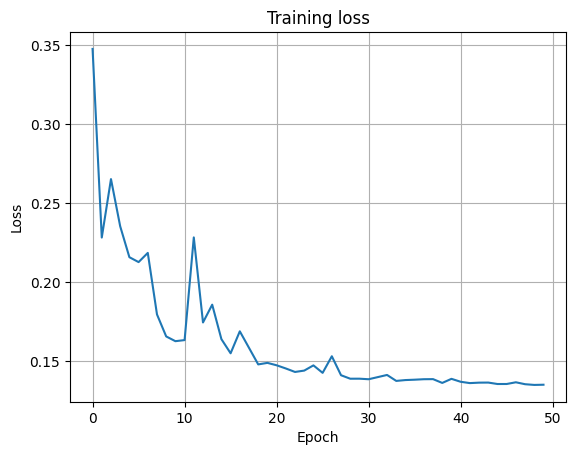

In [16]:
import matplotlib.pyplot as plt

plt.plot(avg_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()